# Defect concentrations

Defect concentrations are a crucial piece of information that we can extract with point defects thermodynamics. The function to compute defect concentration is defined at the `DefectEntry` level ([Entries](./entries.ipynb)). When using the ideal solution approach in thermodynamic equilibrium, the number of defects $n$ is defined as:

$$ n = N \frac{1}{e^{\beta \Delta G_f} + 1} $$

where $N$ is the number of lattice sites and $\beta$ is $1/k_B T$. If $n << N$, we can rewrite it as:

$$ n = N \; e^{- \beta \Delta G_f} $$

which in textbooks is the most commonly reported version. The two expressions are practically equivalent if $\Delta G_f > 80 \mathrm{meV}$ for $k_B T = 25 \mathrm{meV}$. In other words, unless the formation energy is too small, it does not matter which expression we choose. `defermi` uses the first expression, which properly captures the occupation for small formation energies, if we assume that defects do not interact with each other. Depending on how we express $N$, we obtain the concentrations either per unit volume (conventionally in $\mathrm{cm}^-3$) or per unit cell.

In this tutorial, we learn how to analyse concentrations collectively, when looking at a collection of individual defect entries with the `DefectsAnalysis` class. First, we initialize the class with our usual example.

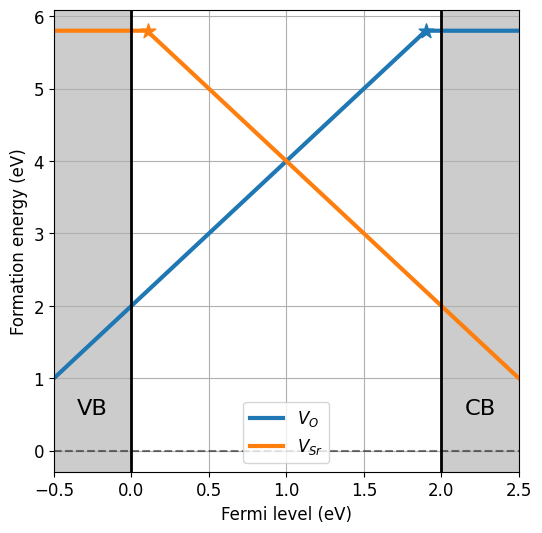

In [10]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)

chempots = {'O':-5,'Sr':-2,'Ti':-8,'Fe':-8.5}
da.plot_formation_energies(chempots);

Defect concentrations can be computed for all entries with the `defect_concentrations` method. Since concentrations depend on the formation energies, we need to provide the chemical potentials and the Fermi level:

In [16]:
conc = da.defect_concentrations(chemical_potentials={'O':-5,'Sr':-2},temperature=1000,fermi_level=1)
conc

[charge=0.0, conc=7.35e-09, name=Vac_O
charge=2.0, conc=8.67e+00, name=Vac_O
charge=-2.0, conc=8.67e+00, name=Vac_Sr
charge=0.0, conc=7.35e-09, name=Vac_Sr]

In [22]:
print(f"Total concentrations:\n {conc.total}\n")
print(f"Stable charge states concentrations:\n {conc.stable}\n")
print(f"Concentrations of each element:\n {conc.elemental}\n")

Total concentrations:
 {'Vac_O': np.float64(8.66557273790188), 'Vac_Sr': np.float64(8.66557273790188)}

Stable charge states concentrations:
 [charge=2.0, conc=8.67e+00, name=Vac_O
charge=-2.0, conc=8.67e+00, name=Vac_Sr]

Concentrations of each element:
 {'Vac_O': np.float64(8.66557273790188), 'Vac_Sr': np.float64(8.66557273790188)}



The object provides functionalities and attributes to collectively analyse the concentrations. For example:
- `total`: Sum concentrations of all charge states for each defect, returns a dictionary as `{name:total_conc}`
- `stable`: Return only the stable charge states for each defect, returns another `DefectConcentrations` object
- `elemental`: Sum concentrations of all defects in all charge states for each element. Vacancies of an element are considered a separate element

### Fixed concentrations



In [12]:
{'name': 'Sub_Fe_on_Sr','charge': -1,'multiplicity': 1,'energy_diff': 3.9,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge':0,'multiplicity':1,'energy_diff': 3.5, 'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 1,'multiplicity': 1,'energy_diff': 7.0,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 2,'multiplicity': 1,'energy_diff': 6.5,'bulk_volume': bulk_volume};

The output is a `DefectConcentrations` object, which behaves as a list of dictionaries, with keys:
- `"name"`
- `"charge"`
- `"conc"` : Concentration value

 Here the reference material is $\mathrm{SrTiO}_3$ and we include substitutions with $\mathrm{Fe}$ both on $\mathrm{Sr}$ and on $\mathrm{Ti}$ sites. 